# 🔗 Hands-On Bab 6 — Deteksi Komunitas
### Analisis Jaringan Sosial: Konsep, Metode, dan Aplikasi

Notebook ini mengimplementasikan **Girvan-Newman** dan **Louvain** untuk deteksi komunitas, mereproduksi contoh graf 8 simpul dari buku, dan mengerjakan **Latihan Soal Bab 6** — yang seluruhnya berbasis pemrograman pada dataset Zachary's Karate Club.

In [1]:
!pip install -q networkx matplotlib
import networkx as nx
import matplotlib.pyplot as plt

## 6.2.1 Girvan-Newman: Reproduksi Contoh 8 Simpul

Reproduksi graf dari buku (8 simpul, 11 sisi) di mana sisi (4,5) memiliki edge betweenness tertinggi dan menjadi jembatan antarkomunitas.

Sisi dengan edge betweenness tertinggi: (4, 5) = 0.57
(Buku: sisi (4,5) dengan EB = 16.00 -- bandingkan skala relatifnya)


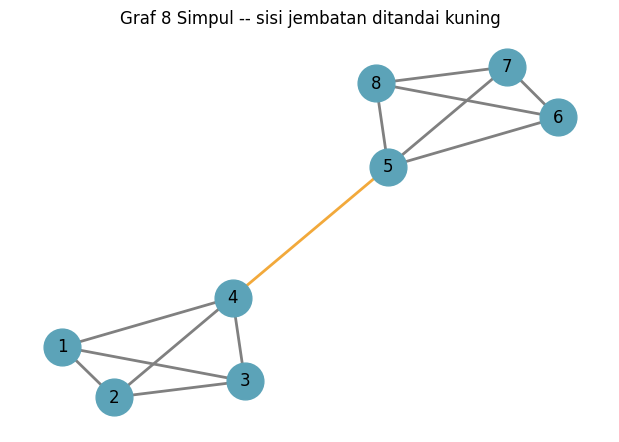

In [2]:
G_gn = nx.Graph()
G_gn.add_edges_from([
    (1,2), (1,3), (1,4), (2,3), (2,4), (3,4),   # kelompok kiri {1,2,3,4}
    (4,5),                                        # jembatan
    (5,6), (5,7), (5,8), (6,7), (6,8), (7,8)     # kelompok kanan {5,6,7,8}
])

edge_betweenness = nx.edge_betweenness_centrality(G_gn)
sisi_tertinggi = max(edge_betweenness, key=edge_betweenness.get)
print(f"Sisi dengan edge betweenness tertinggi: {sisi_tertinggi} = {edge_betweenness[sisi_tertinggi]:.2f}")
print("(Buku: sisi (4,5) dengan EB = 16.00 -- bandingkan skala relatifnya)")

plt.figure(figsize=(6,4))
pos = nx.spring_layout(G_gn, seed=1)
edge_colors = ["#F2A93B" if e == sisi_tertinggi else "gray" for e in G_gn.edges()]
nx.draw(G_gn, pos, with_labels=True, node_color="#5CA3B8", node_size=700, edge_color=edge_colors, width=2)
plt.title("Graf 8 Simpul -- sisi jembatan ditandai kuning")
plt.show()

In [3]:
# Jalankan algoritma Girvan-Newman selangkah demi selangkah
gn_generator = nx.community.girvan_newman(G_gn)
first_split = next(gn_generator)
print("Partisi setelah iterasi pertama:", [sorted(c) for c in first_split])

modularity_gn = nx.community.modularity(G_gn, first_split)
print(f"Modularity Q = {modularity_gn:.3f}  (buku: Q = 0.371 pada partisi optimal)")

Partisi setelah iterasi pertama: [[1, 2, 3, 4], [5, 6, 7, 8]]
Modularity Q = 0.423  (buku: Q = 0.371 pada partisi optimal)


## 6.2.2 Louvain: Optimisasi Modularitas

In [4]:
louvain_result = nx.community.louvain_communities(G_gn, seed=1)
print("Komunitas hasil Louvain:", [sorted(c) for c in louvain_result])

modularity_louvain = nx.community.modularity(G_gn, louvain_result)
print(f"Modularity Q (Louvain) = {modularity_louvain:.3f}")

Komunitas hasil Louvain: [[1, 2, 3, 4], [5, 6, 7, 8]]
Modularity Q (Louvain) = 0.423


## ✅ Latihan Soal Bab 6

Seluruh soal berikut menggunakan dataset **Zachary's Karate Club** — tersedia langsung di NetworkX melalui `nx.karate_club_graph()`.

**1.** Gunakan Algoritma Girvan-Newman untuk deteksi komunitas pada dataset Karate Club, kemudian hitung modularitasnya!

**2.** Gunakan Algoritma Louvain untuk deteksi komunitas pada dataset Karate Club, kemudian hitung modularitasnya!

**3.** Bandingkan modularitas pada soal 1 dan 2, berikan analisismu!

### 🧮 Soal 1 — Girvan-Newman pada Karate Club

In [ ]:
G_karate = nx.karate_club_graph()

gn_karate = nx.community.girvan_newman(G_karate)

# Cari partisi dengan modularity tertinggi di antara beberapa level pertama
best_partition_gn = None
best_modularity_gn = -1
for i, partition in enumerate(gn_karate):
    q = nx.community.modularity(G_karate, partition)
    if q > best_modularity_gn:
        best_modularity_gn = q
        best_partition_gn = partition
    if i >= 8:  # cukup telusuri beberapa level pertama
        break

print(f"Jumlah komunitas terbaik : {len(best_partition_gn)}")
print(f"Modularity terbaik (GN)  : {best_modularity_gn:.4f}")

### 🧮 Soal 2 — Louvain pada Karate Club

In [ ]:
louvain_karate = nx.community.louvain_communities(G_karate, seed=42)
modularity_louvain_karate = nx.community.modularity(G_karate, louvain_karate)

print(f"Jumlah komunitas (Louvain): {len(louvain_karate)}")
print(f"Modularity (Louvain)      : {modularity_louvain_karate:.4f}")

# Visualisasi hasil
color_map = {}
for i, community in enumerate(louvain_karate):
    for node in community:
        color_map[node] = i
colors = [color_map[n] for n in G_karate.nodes()]

plt.figure(figsize=(6,5))
pos = nx.spring_layout(G_karate, seed=42)
nx.draw(G_karate, pos, with_labels=True, node_color=colors, cmap=plt.cm.Set2, node_size=500)
plt.title(f"Deteksi Komunitas Louvain -- {len(louvain_karate)} komunitas, Q={modularity_louvain_karate:.3f}")
plt.show()

### ✏️ Soal 3 — Analisis Perbandingan (tulis di sini)

Bandingkan nilai modularity dari Girvan-Newman (Soal 1) dan Louvain (Soal 2) yang telah dihitung di atas. Tuliskan analisis Anda:

_Analisis:_

In [ ]:
print(f"Modularity Girvan-Newman : {best_modularity_gn:.4f}")
print(f"Modularity Louvain       : {modularity_louvain_karate:.4f}")
print(f"Selisih                  : {abs(best_modularity_gn - modularity_louvain_karate):.4f}")
print()
print("Catatan: kedua algoritma dapat menghasilkan modularity yang berbeda")
print("karena strategi optimasinya berbeda (divisif hierarkis vs. optimisasi lokal iteratif).")
print("Louvain umumnya lebih cepat, sementara Girvan-Newman lebih presisi pada jaringan kecil.")

---
### 📚 Referensi
Bab 6 — *Deteksi Komunitas*, dalam **Analisis Jaringan Sosial: Konsep, Metode, dan Aplikasi**.

Lanjutkan ke **Notebook Bab 7 — Jaringan Dinamis**.